# **House Price Prediction using Advance Reggression:**
* **[EDA](#intLink)**
* **[Pre-Processing](#intLink2)**
  * **[Handling Missing Data](#intLink3)**
  * **[Handling Outliners](#intLink4)**   
* **[Lineer Reggresion](#intLink5)**
* **[polynomial Regression](#intLink6)**
* **[Regularization (Ridge - LASSO - ElasticNet)](#intLink7)**


In [2]:
#loading necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
#loading train and test from house-prices dataset
train_set = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
test_set = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')
test_label = pd.read_csv('../input/house-prices-advanced-regression-techniques/sample_submission.csv')

In [ ]:
test_set.shape

In [ ]:
test_set.shape

In [5]:
#adding test label
test_set["SalePrice"] =test_label['SalePrice']

In [8]:
#combining the train and test set for cleaning
#df_final= pd.concat([train_set,test_set])
df_final = pd.concat([test_set.assign(ind="test_set"), train_set.assign(ind="train_set")])

# <div id="intLink"> EDA </div>

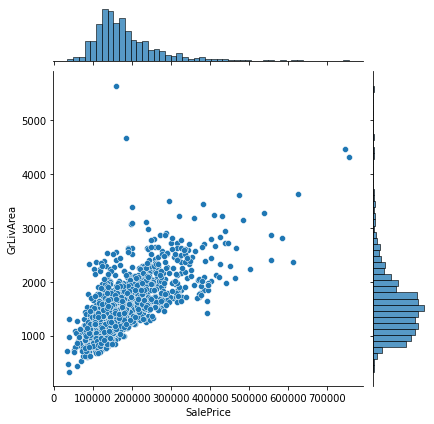

In [9]:
# correlation between 'SalePrice' and 'GrLivArea' 
# we can spot outliners that we delete later on
sns.jointplot(data=train_set, x='SalePrice', y='GrLivArea')

<AxesSubplot:xlabel='OverallQual', ylabel='SalePrice'>

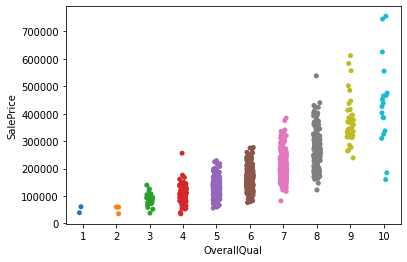

In [10]:
#OverallQual is the most corr feature we can see the Linear shape and no outliner
figure=figsize = (30,34)
sns.stripplot(data=train_set, x = 'OverallQual', y='SalePrice')

# <div id="intLink2"> Pre-Processing # 
1. Handling missing value
2. High/Low Correletion data
3. Categorical Data
4. Numerical Columns to Categorical
5. Dealing with Outliers
6. Creating Dummy Variables
one-hot-encodding </div>

#  <div id="intLink3">1.Handling **missing** Values
* Dropping columns with more than 70% null_value and Id (it might not be the best case for every problem or dataset).
* Handling null value in the rest of thr features</div>

> 

In [10]:
#finding features with the most duplicant value ?

In [11]:

def missing_percent(train_set):
    nan_percent = 100*(train_set.isnull().sum()/len(train_set))
    nan_percent = nan_percent[nan_percent>0].sort_values(ascending=False).round(1)
    DataFrame = pd.DataFrame(nan_percent)
    # Rename the columns
    mis_percent_table = DataFrame.rename(columns = {0 : '% of Misiing Values'}) 
    # Sort the table by percentage of missing descending
    mis_percent = mis_percent_table
    return mis_percent


In [12]:
miss = missing_percent(train_set)
miss

,% of Misiing Values
PoolQC,99.5
MiscFeature,96.3
Alley,93.8
Fence,80.8
FireplaceQu,47.3
LotFrontage,17.7
GarageType,5.5
GarageYrBlt,5.5
GarageFinish,5.5
GarageQual,5.5


In [13]:
#Removing the Id that has no value for our prediction
train_set= train_set.drop('Id', axis=1)

In [14]:
nan_percent = 100*(train_set.isnull().sum()/len(train_set))
nan_percent = nan_percent[nan_percent>0].sort_values()

(0.0, 1.0)

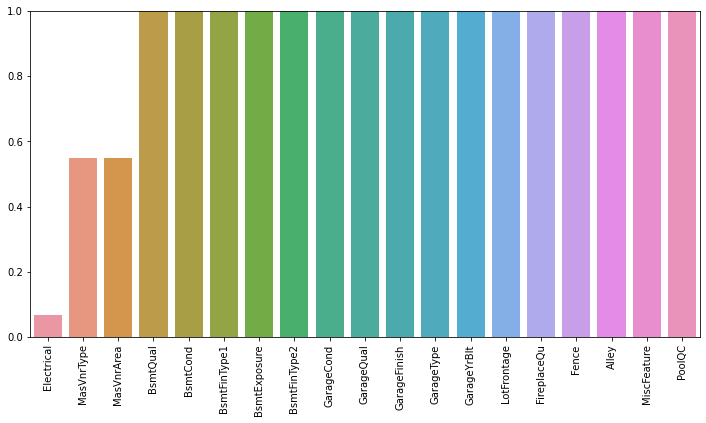

In [15]:
# Every Feature with missing data must be checked!
# We choose a threshold of 1%. It means, if there is less than 1% of a feature are missing

plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)

#Set 1% threshold:
plt.ylim(0,1)

In [16]:
train_set.shape

(1460, 80)

In [17]:
#Removing the Id that has no value for our prediction
train_set= train_set.drop('Id', axis=1)

KeyError: "['Id'] not found in axis"

In [18]:
#drop features that have more than 70% missing value
#credit: https://www.kaggle.com/rushikeshdarge/handle-missing-values-only-notebook-you-need
threshold = 70
drop_cols = miss[miss['% of Misiing Values'] > threshold].index.tolist()
drop_cols


['PoolQC', 'MiscFeature', 'Alley', 'Fence']

In [19]:
train_set= train_set.drop(drop_cols, axis=1)

In [20]:
nan_percent = 100*(train_set.isnull().sum()/len(train_set))
nan_percent = nan_percent[nan_percent>0].sort_values()

(0.0, 1.0)

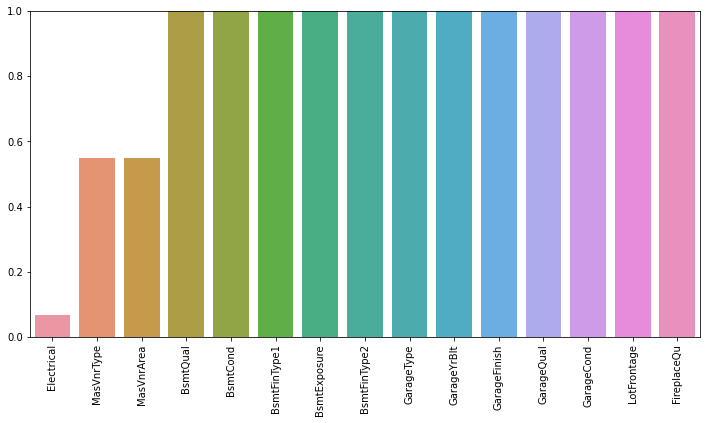

In [21]:
#every Feature with missing data must be checked!
#We choose a threshold of 1%. It means, if there is less than 1% of a feature are missing

plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)

#Set 1% threshold:
plt.ylim(0,1)

**FireplaceQu: Fireplace quality**
* acoording to the data this feature has an NA value that means the house has no fire place so we fill the column with 'None'

In [22]:
train_set['FireplaceQu']= train_set['FireplaceQu'].fillna('None')

In [ ]:
#Filling null values most freq value
#train_set['KitchenQual']= train_set['KitchenQual'].fillna('TA')

In [ ]:
#df_final['SaleType']= df_final['SaleType'].fillna('Oth')

In [ ]:
#df_final['Functional']= df_final['Functional'].fillna('Typ')

In [ ]:
#df_final['Exterior1st']= df_final['Exterior1st'].fillna('Other')
#df_final.fillna({'Exterior1st':'Other', 'Exterior2nd':'Other', 'Utilities':'Other'}, inplace=True)

**Garage & Bacement**
* by looking at the plot we realize that most features with missing value are from the same catagories.

In [23]:
#After checking the data documentation,
#it shows that missing value (two rows) in Basement Features are becouse of there is no basement in these rows
#Decision: Filling in data based on column: numerical basement & string descriptive:

#Numerical Columns fill with 0:
bsmt_num_cols= ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF' ,'BsmtFullBath', 'BsmtHalfBath']
train_set[bsmt_num_cols]=train_set[bsmt_num_cols].fillna(0)

#String Columns fill with None:
bsmt_str_cols= ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
train_set[bsmt_str_cols]= train_set[bsmt_str_cols].fillna('None')

**Mas Vnr Features:**

* Based on the Dataset Document File, missing values for 'Mas Vnr Type' and 'Mas Vnr Area' means the house doesn't have any mansonry veneer. so, we decide to fill the missing value as below:

In [24]:
train_set["MasVnrType"]= train_set["MasVnrType"].fillna("None")
train_set["MasVnrArea"]= train_set["MasVnrArea"].fillna(0)

**Garage Columns:**
* Based on the dataset documentation, NaN in Garage Columns seems to indicate no garage.

* Decision: Fill with 'None' or 0

In [25]:
train_set[['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']]

,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond
0,Attchd,2003.0,RFn,TA,TA
1,Attchd,1976.0,RFn,TA,TA
2,Attchd,2001.0,RFn,TA,TA
3,Detchd,1998.0,Unf,TA,TA
4,Attchd,2000.0,RFn,TA,TA
...,...,...,...,...,...
1455,Attchd,1999.0,RFn,TA,TA
1456,Attchd,1978.0,Unf,TA,TA
1457,Attchd,1941.0,RFn,TA,TA
1458,Attchd,1950.0,Unf,TA,TA


In [ ]:
#now we will extract all the numerical features from the dataset
#numerical_features= [feature for feature in train_set.columns if train_set[feature].dtypes !='O']

#print('Number of Numerical Features:',len(numerical_features))

#train_set[numerical_features].head(5)

In [ ]:
#now we will extract datatime features from the dataset
#year_feature=[feature for feature in numerical_features if 'Year' in feature or 'Yr' in feature]

#print('Number of Yearly Features:',len(year_feature))
#train_set[year_feature].head(5)

In [ ]:
#now we will analyze yearly features wrt SalePrice which is our independent feature
#for feature in year_feature:
    
    
 #   train_set.groupby(feature)['SalePrice'].median().plot()
  #  plt.show()

In [26]:
#Filling the missing Value:
Gar_str_cols= ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
train_set[Gar_str_cols]=train_set[Gar_str_cols].fillna('None')

train_set['GarageYrBlt']=train_set['GarageYrBlt'].fillna(0)

In [27]:
#Impute missing data based on other columns:

train_set.groupby('Neighborhood')['LotFrontage']

In [28]:
train_set.groupby('Neighborhood')['LotFrontage'].mean()

Neighborhood
Blmngtn    47.142857
Blueste    24.000000
BrDale     21.562500
BrkSide    57.509804
ClearCr    83.461538
CollgCr    71.682540
Crawfor    71.804878
Edwards    68.217391
Gilbert    79.877551
IDOTRR     62.500000
MeadowV    27.800000
Mitchel    70.083333
NAmes      76.462366
NPkVill    32.285714
NWAmes     81.288889
NoRidge    91.878788
NridgHt    81.881579
OldTown    62.788991
SWISU      58.913043
Sawyer     74.437500
SawyerW    71.500000
Somerst    64.666667
StoneBr    62.700000
Timber     80.133333
Veenker    59.714286
Name: LotFrontage, dtype: float64

In [29]:
#Filling null values mean value
train_set.groupby('Neighborhood')['LotFrontage'].transform(lambda val: val.fillna(val.mean()))

0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64

In [30]:
train_set['LotFrontage']=train_set.groupby('Neighborhood')['LotFrontage'].transform(lambda val: val.fillna(val.mean()))

In [ ]:
#Filling null values most freq value
#train_set['MSZoning'].value_counts()[train_set['MSZoning'].value_counts() == df_final['MSZoning'].value_counts().max()].index


In [ ]:
#train_set['MSZoning']=train_set['MSZoning'].fillna('RL')

In [31]:
train_set['LotFrontage']=train_set['LotFrontage'].fillna(0)

In [32]:
train_set[train_set['GarageArea'].isnull()]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


# Handling test_set null value 
* Functional
* Exterior1st    
* Exterior2nd    
* KitchenQual    
* SaleType       
* Utilities      
* Functional     
* MSZoning

In [33]:
#Filling null values most freq value
train_set['LotFrontage']=train_set.groupby('Neighborhood')['LotFrontage'].transform(lambda val: val.fillna(val.max()))

In [ ]:
#Filling null values most freq value
#train_set['Functional'].value_counts()[train_set['Functional'].value_counts() == train_set['Functional'].value_counts().max()].index

In [34]:
nan_percent = 100*(train_set.isnull().sum()/len(df_final))
nan_percent = nan_percent[nan_percent>0].sort_values()

(array([0]), [Text(0, 0, 'Electrical')])

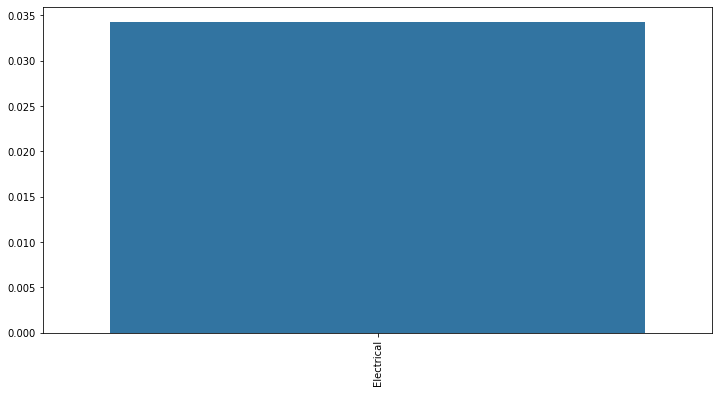

In [35]:
#plot the feature with missing indicating the percent of missing data
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)

In [36]:
train_set= train_set.dropna(axis=0, subset=['Electrical', 'GarageArea'])

In [ ]:
#Filling null values most freq value
#df_final['MSZoning'].value_counts()[df_final['MSZoning'].value_counts() == df_final['MSZoning'].value_counts().max()].index


In [ ]:
#df_final['MSZoning']= df_final['MSZoning'].transform(lambda val: val.fillna(val.max()))

In [37]:
df_final.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      486
LotArea            0
                ... 
YrSold             0
SaleType           1
SaleCondition      0
SalePrice          0
ind                0
Length: 82, dtype: int64

**Finally we check if there is more null value in the dataset**

In [38]:
nan_percent= missing_percent(train_set)

In [39]:
nan_percent = 100*(train_set.isnull().sum()/len(df_final))
nan_percent = nan_percent[nan_percent>0].sort_values()

In [40]:
nan_percent

Series([], dtype: float64)

In [ ]:
#df = pd.concat([test.assign(ind="test"), train.assign(ind="train")])

In [41]:
train_set.shape

(1459, 76)

# <div id="intLink4"> Handling Outliers</div>

In [42]:
from sklearn.neighbors import LocalOutlierFactor
#credit https://www.kaggle.com/hrshtporwal5/houseprice-prediction
def detect_outliers(x, y, top=5, plot=True):
    lof = LocalOutlierFactor(n_neighbors=40, contamination=0.1)
    x_ =np.array(x).reshape(-1,1)
    preds = lof.fit_predict(x_)
    lof_scr = lof.negative_outlier_factor_
    out_idx = pd.Series(lof_scr).sort_values()[:top].index
    if plot:
        f, ax = plt.subplots(figsize=(9, 6))
        plt.scatter(x=x, y=y, c=np.exp(lof_scr), cmap='RdBu')
    return out_idx

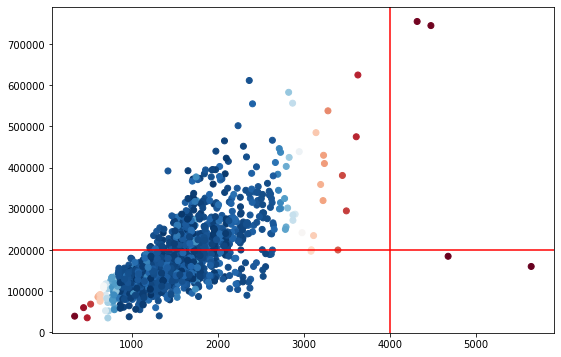

In [43]:
#GrLivArea-SalePrice outlier detection
outs = detect_outliers(train_set['GrLivArea'], train_set['SalePrice'],top=5) 
outs
plt.axhline(y=200000, color='r')
plt.axvline(x=4000, color='r')
#credit https://www.kaggle.com/hrshtporwal5/houseprice-prediction

In [ ]:
#train_set[(train_set['OverallQual']>8) &(train_set['SalePrice']<200000)][['SalePrice', 'OverallQual']]

In [ ]:
#corr = train_set.corr()
#top_corr_features = corr.index[abs(corr["SalePrice"])>0.5].sort_values(ascending=True)


In [44]:
#Remove the outliers:
index_drop=train_set[(train_set['GrLivArea']>4000) & (train_set['SalePrice']<400000)].index
train_set=train_set.drop(index_drop, axis=0)

GrLivArea without outliner

In [45]:
#Remove the outliers:
index_drop=train_set[(train_set['GrLivArea']>4000) & (train_set['SalePrice']>400000)].index
train_set=train_set.drop(index_drop, axis=0)

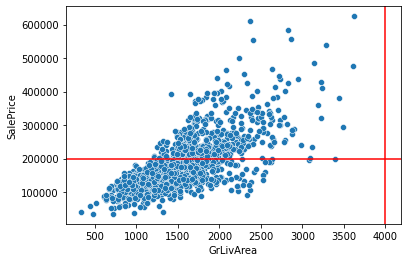

In [46]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train_set)
plt.axhline(y=200000, color='r')
plt.axvline(x=4000, color='r')

<AxesSubplot:xlabel='OverallQual', ylabel='SalePrice'>

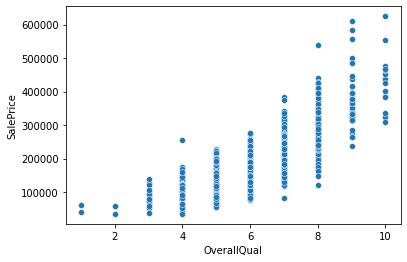

In [47]:
sns.scatterplot(x='OverallQual', y='SalePrice', data=train_set)
#no need to remove any data

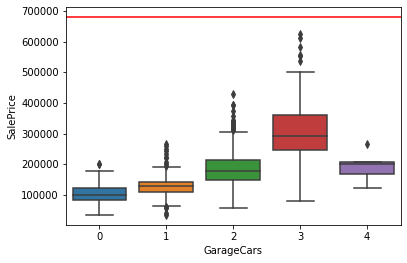

In [48]:
sns.boxplot(x='GarageCars', y='SalePrice', data=train_set)
plt.axhline(y=680000,color='r')


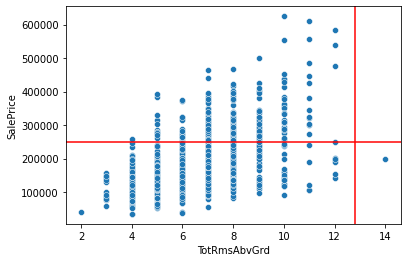

In [49]:
sns.scatterplot(data=train_set, x='TotRmsAbvGrd', y='SalePrice')
plt.axhline(y=250000, color='r')
plt.axvline(x=12.8, color='r')

In [50]:
train_set[(train_set['TotRmsAbvGrd']>12.7) & (train_set['SalePrice']<250000)][['SalePrice', 'TotRmsAbvGrd']]

,SalePrice,TotRmsAbvGrd
635,200000,14


In [51]:
#Remove the outliers:
index_drop=train_set[(train_set['TotRmsAbvGrd']>12.7) & (train_set['SalePrice']<250000)].index
train_set=train_set.drop(index_drop, axis=0)

<AxesSubplot:xlabel='TotRmsAbvGrd', ylabel='SalePrice'>

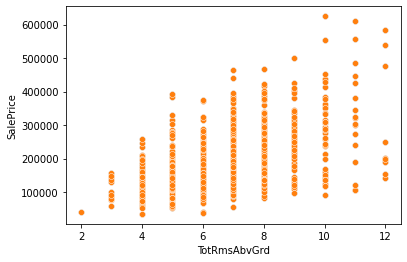

In [52]:
sns.scatterplot(data=train_set, x='TotRmsAbvGrd', y='SalePrice')
sns.scatterplot(data=train_set, x='TotRmsAbvGrd', y='SalePrice')

# Features that have high correlation (higher than 0.5)

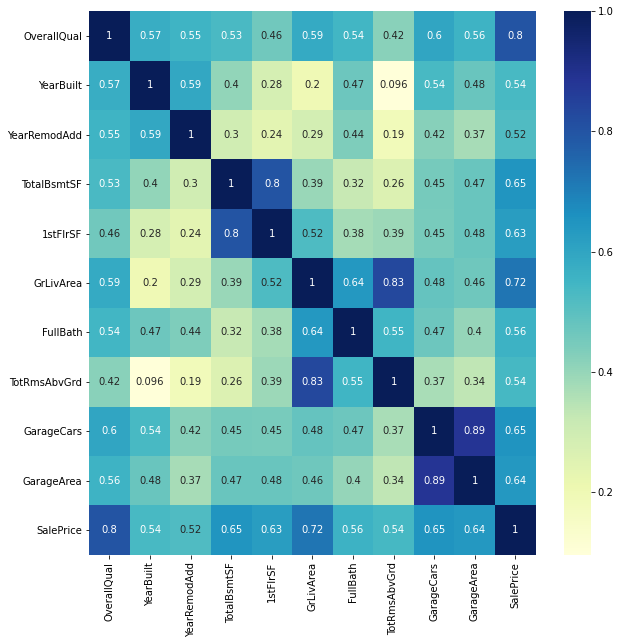

In [53]:
# get correlations of each features in dataset
# Plotting Heat Map to visualise correlation data better. 
# Drwan for only features having high correlation 
# (>0.5) with Target Variable
corr = train_set.corr()
top_corr_features = corr.index[abs(corr["SalePrice"])>0.5]

plt.figure(figsize=(10,10))
#plot heat map
g=sns.heatmap(train_set[top_corr_features].corr(),annot=True,cmap="YlGnBu")

Text(0.5, 1.0, 'House Price vs YearSold')

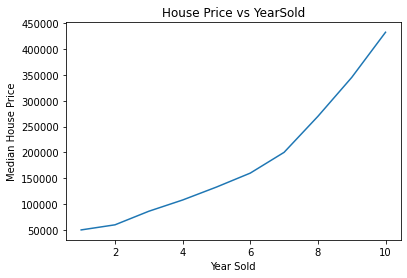

In [54]:
#this shows that Houses become more expensive with time
train_set.groupby('OverallQual')['SalePrice'].median().plot()
plt.xlabel('Year Sold')
plt.ylabel('Median House Price')
plt.title("House Price vs YearSold")

In [55]:
top_corr_features

Index(['OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF',
       'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea',
       'SalePrice'],
      dtype='object')

#  Dealing with Categorical Data

In [56]:
#Convert to String:
train_set['MSSubClass']= train_set['MSSubClass'].apply(str)

**Creating Dummy Variables**

In [57]:
train_set.select_dtypes(include='object')

,MSSubClass,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,60,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Gd,Typ,None,Attchd,RFn,TA,TA,Y,WD,Normal
1,20,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,60,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,70,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,60,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
1456,20,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,TA,Min1,TA,Attchd,Unf,TA,TA,Y,WD,Normal
1457,70,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,...,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,WD,Normal
1458,20,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Gd,Typ,None,Attchd,Unf,TA,TA,Y,WD,Normal


In [58]:
train_set_num= train_set.select_dtypes(exclude='object')
train_set_obj= train_set.select_dtypes(include='object')

In [59]:
# Converting:
train_set_obj= pd.get_dummies(train_set_obj, drop_first=True)

In [60]:
Final_df= pd.concat([train_set_num, train_set_obj], axis=1)

# <div id="intLink5">**Linear Reggression**
* we start our path with simple Linear Regression and then we try to improve our model</div>

In [61]:
#Separate features and target from train_df
X = Final_df.drop('SalePrice',axis = 1)
y = Final_df['SalePrice']

In [ ]:
#X = X.apply(pd.to_numeric, errors='coerce')
#y = y.apply(pd.to_numeric, errors='coerce')

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [63]:
#Split the Dataset to Train & Test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=100)

In [64]:
#train the model
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [65]:
#predicting test data
y_pred=model.predict(X_test)

In [66]:
#evaluating the model
from sklearn import metrics
MAE=metrics.mean_absolute_error(y_test,y_pred)
MSE=metrics.mean_squared_error(y_test,y_pred)
RMSE=np.sqrt(MSE)

In [67]:
#coeficient matrix
pd.DataFrame(model.coef_,X.columns,columns=["coeficient"])

,coeficient
LotFrontage,110.031600
LotArea,0.837305
OverallQual,5285.757231
OverallCond,5140.294914
YearBuilt,383.881629
...,...
SaleCondition_AdjLand,4580.387418
SaleCondition_Alloca,17788.073248
SaleCondition_Family,356.392081
SaleCondition_Normal,6867.958206


In [68]:
pd.DataFrame(data=[MAE,MSE,RMSE],index=["MAE","MSE","RMSE"],columns=["LinearRegression"])

,LinearRegression
MAE,1.699453e+04
MSE,6.548139e+08
RMSE,2.558933e+04


# <div id="intLink6">Polynomial Regression improves our model
* Polynomial Regression adding more relevant features</div>

In [69]:
from sklearn.preprocessing import PolynomialFeatures

polynomial_converter=PolynomialFeatures(degree=2, include_bias=False)

In [70]:
poly_features=polynomial_converter.fit(X)

In [71]:
poly_features=polynomial_converter.transform(X)

# Poly_Features: 
(X1, X2, X3, X1^2, X2^2, X3^2, X1X2, X1X3, X2X3)
* Split the Data to Train & Test
* Train the Model

In [72]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

In [73]:
from sklearn.linear_model import LinearRegression
polymodel=LinearRegression()
polymodel.fit(X_train, y_train)

LinearRegression()

In [74]:
y_pred=polymodel.predict(X_test)

In [75]:
pd.DataFrame({'Y_Test': y_test,'Y_Pred':y_pred, 'Residuals':(y_test-y_pred) }).head(5)

,Y_Test,Y_Pred,Residuals
304,295000,347804.103144,-52804.103144
337,214000,234407.745728,-20407.745728
862,152000,167020.396864,-15020.396864
198,104000,-154719.702630,258719.702630
1150,124000,122682.669389,1317.330611


In [76]:
from sklearn import metrics
MAE_Poly = metrics.mean_absolute_error(y_test,y_pred)
MSE_Poly = metrics.mean_squared_error(y_test,y_pred)
RMSE_Poly = np.sqrt(MSE_Poly)

pd.DataFrame([MAE_Poly, MSE_Poly, RMSE_Poly], index=['MAE', 'MSE', 'RMSE'], columns=['metrics'])

,metrics
MAE,6.111567e+04
MSE,3.605530e+10
RMSE,1.898823e+05


# Polymodel Regression vs Linear Regression
* **RMSE decresed significeantly**

In [77]:
XS_train, XS_test, ys_train, ys_test = train_test_split(X, y, test_size=0.3, random_state=101)
simplemodel=LinearRegression()
simplemodel.fit(XS_train, ys_train)
ys_pred=simplemodel.predict(XS_test)

MAE_simple = metrics.mean_absolute_error(ys_test,ys_pred)
MSE_simple = metrics.mean_squared_error(ys_test,ys_pred)


In [78]:
RMSE_simple = np.sqrt(MSE_simple)

In [79]:
pd.DataFrame({'Poly Metrics': [MAE_Poly, MSE_Poly, RMSE_Poly], 'Simple Metrics':[MAE_simple, MSE_simple, RMSE_simple]}, index=['MAE', 'MSE', 'RMSE'])

,Poly Metrics,Simple Metrics
MAE,6.111567e+04,1.739029e+04
MSE,3.605530e+10,6.293503e+08
RMSE,1.898823e+05,2.508686e+04


# <div id="intLink7">Regularization
* [Scaling the Data](#intLink8)
* [Ridge Regression(Cross-Validation)](#intLink9)


In [92]:
X = Final_df.drop('SalePrice',axis = 1)
y = Final_df['SalePrice']

In [93]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter= PolynomialFeatures(degree=2, include_bias=False)
poly_features= polynomial_converter.fit_transform(X)

In [94]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

Scaling the Data<div id="intLink8">

In [95]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [96]:
X_train= scaler.transform(X_train)
X_test= scaler.transform(X_test)

Ridge Regression<div id="intLink9">


In [97]:
#Train the Model
from sklearn.linear_model import Ridge
ridge_model= Ridge(alpha=10)

In [98]:
ridge_model.fit(X_train, y_train)

Ridge(alpha=10)

In [99]:
#predict Test Data
y_pred= ridge_model.predict(X_test)

In [100]:
#Evaluating the Model
from sklearn.metrics import mean_absolute_error, mean_squared_error

MAE= mean_absolute_error(y_test, y_pred)
MSE= mean_squared_error(y_test, y_pred)
RMSE= np.sqrt(MSE)

In [101]:
pd.DataFrame([MAE, MSE, RMSE], index=['MAE', 'MSE', 'RMSE'], columns=['metrics'])

,metrics
MAE,1.951440e+04
MSE,7.616511e+08
RMSE,2.759803e+04


In [114]:
#Train the Model
from sklearn.linear_model import RidgeCV
ridge_cv_model=RidgeCV(alphas=(0.1, 1.0, 10.0), scoring='neg_mean_absolute_error')

In [115]:
ridge_cv_model.fit(X_train, y_train)

RidgeCV(alphas=array([ 0.1,  1. , 10. ]), scoring='neg_mean_absolute_error')

In [116]:
ridge_cv_model.alpha_

10.0

In [117]:
#Predicting Test Data
y_pred_ridge= ridge_cv_model.predict(X_test)

In [118]:
MAE_ridge= mean_absolute_error(y_test, y_pred_ridge)
MSE_ridge= mean_squared_error(y_test, y_pred_ridge)
RMSE_ridge= np.sqrt(MSE_ridge)

In [119]:
pd.DataFrame([MAE_ridge, MSE_ridge, RMSE_ridge], index=['MAE', 'MSE', 'RMSE'], columns=['Ridge Metrics'])

,Ridge Metrics
MAE,1.951440e+04
MSE,7.616511e+08
RMSE,2.759803e+04


Lasso Regression<div id="intLink11">


In [123]:
from sklearn.linear_model import LassoCV
lasso_cv_model= LassoCV(eps=0.01, n_alphas=100, cv=5)

In [ ]:
lasso_cv_model.alpha_

In [ ]:
y_pred_lasso= lasso_cv_model.predict(X_test)

In [ ]:
MAE_Lasso= mean_absolute_error(y_test, y_pred_lasso)
MSE_Lasso= mean_squared_error(y_test, y_pred_lasso)
RMSE_Lasso= np.sqrt(MSE_Lasso)

In [ ]:
pd.DataFrame([MAE_Lasso, MSE_Lasso, RMSE_Lasso], index=['MAE', 'MSE', 'RMSE'], columns=['Lasso Metrics'])

Elastic Net<div id="intLink12">